**TO TEST FOR WHICH COMMUNITY SPLIT TO USE**

Testing each community split algorithm on the data to compare for accuracy, f1 score and modularity, to determine which to use

In [124]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from community import community_louvain 
from networkx.algorithms.community import kernighan_lin_bisection
from networkx.algorithms.community.quality import modularity


In [125]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [126]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [127]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth'))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)

    return df_data, republican_df, democratic_df

In [128]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [129]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [130]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'], strength=row['strength'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [131]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [132]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [133]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [134]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    mod_value = modularity(G, communities)
    print(f"Modularity of the two-community split: {mod_value}")

    # Determine party alignment in the identified communities
    # alignment = {1: {'R': 0, 'D': 0}, 2: {'R': 0, 'D': 0}}
    # for node in G.nodes():
    #     party = G.nodes[node]['party']
    #     community_id = node_to_community[node]
    #     alignment[community_id][party] += 1
    alignment = political_alignment(G, communities)
    # print("\nCommunity-party alignment:")
    # for community_id, counts in alignment.items():
    #     print(f"Community {community_id}: {counts}")
    comm_label = classify_communities(alignment)

    return communities, alignment, mod_value, comm_label

In [135]:
def apply_kernighan_lin(G):
    """Applies Kernighan-Lin bisection algorithm to graph G."""
    # The graph G should have its nodes with an attribute 'party' (either 'R' or 'D')
    partition = kernighan_lin_bisection(G)
    
    # Analyze alignment with political parties
    alignment = {1: {"R": 0, "D": 0}, 2: {"R": 0, "D": 0}}
    for idx, part in enumerate(partition):
        for node in part:
            party = G.nodes[node]['party']
            alignment[idx+1][party] += 1

    # Calculate modularity value
    mod_value = modularity(G, partition)

    print(f"Modularity of the partition: {mod_value}")
    # print("Party alignment in communities:", alignment)
    comm_label = classify_communities(alignment)

    return partition, alignment, mod_value, comm_label

In [136]:
from networkx.algorithms.community import girvan_newman
from itertools import islice

def apply_girvan_newman_two_partitions(G):
    """Applies the Girvan-Newman algorithm and merges the results into two communities if necessary.

    Args:
        G (networkx.Graph): The graph on which to perform the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Run Girvan-Newman algorithm to get an initial community division
    comp_gen = girvan_newman(G)
    initial_communities = next(islice(comp_gen, 1))  # Get the first result of the Girvan-Newman generator

    # Merge communities into two
    if len(initial_communities) > 2:
        # communities = merge_communities_by_edge_count(G, initial_communities)
        communities = merge_n_communities_by_edge_count(G, initial_communities, 2)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Initialize alignment dictionary based on the number of communities
    alignment = {i + 1: {'R': 0, 'D': 0} for i in range(len(communities))}

    # Analyze alignment with political parties
    for idx, community in enumerate(communities):
        for node in community:
            party = G.nodes[node]['party']
            alignment[idx + 1][party] += 1

    # Calculate modularity for the two communities
    mod_value = modularity(G, communities)
    print(f"Modularity of the partition: {mod_value}")

    # Classify communities based on dominant party
    comm_labels = classify_communities(alignment)

    return communities, alignment, mod_value, comm_labels

In [137]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

def apply_greedy_modularity_two_partitions(G):
    """Applies greedy modularity community detection and merges results into two communities.

    Args:
        G (networkx.Graph): The graph on which to apply the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Detect communities using greedy modularity maximization
    initial_communities = greedy_modularity_communities(G)
    print(len(initial_communities))

    # Merge communities into two
    if len(initial_communities) > 2:
        # communities = merge_communities_by_edge_count(G, initial_communities)
        communities = merge_n_communities_by_edge_count(G, initial_communities, 2)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Analyze alignment with political parties
    alignment = {1: {'R': 0, 'D': 0}, 2: {'R': 0, 'D': 0}}
    for idx, community in enumerate(communities):
        for node in community:
            party = G.nodes[node]['party']
            alignment[idx + 1][party] += 1

    # Calculate modularity for the two communities
    mod_value = modularity(G, communities)
    print(f"Modularity of the partition: {mod_value}")

    # Classify communities based on dominant party
    comm_labels = classify_communities(alignment)

    return communities, alignment, mod_value, comm_labels

# Example usage:
# G = nx.Graph()  # Assume this graph is populated appropriately with 'party' node attribute
# communities, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)


In [138]:
def calculate_metrics(alignment, community_label):
    """
    Calculate FFC, ARI, RI, and NMI from alignment data and graph nodes.

    Parameters:
        alignment (dict): Alignment data of communities to political parties.
        node_to_community (dict): Mapping of nodes to their assigned community.
        G (Graph): The graph with nodes and party information.

    Returns:
        dict: Calculated metrics.
    """
    # print(community_label[1])
    if community_label[1] == 'Republican':
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    # print(Republican, Democrat)
    # Extract counts
    true_positive_R = alignment[Republican]["R"]
    false_positive_R = alignment[Republican]["D"]
    true_positive_D = alignment[Democrat]["D"]
    false_positive_D = alignment[Democrat]["R"]
    # Precision and Recall for R
    precision_R = true_positive_R / (true_positive_R + false_positive_R) if (true_positive_R + false_positive_R) > 0 else 0
    recall_R = true_positive_R / (true_positive_R + false_positive_D) if (true_positive_R + false_positive_D) > 0 else 0
    
    # Precision and Recall for D
    precision_D = true_positive_D / (true_positive_D + false_positive_D) if (true_positive_D + false_positive_D) > 0 else 0
    recall_D = true_positive_D / (true_positive_D + false_positive_R) if (true_positive_D + false_positive_R) > 0 else 0

    # Macro Average (Optional)
    precision_macro = (precision_R + precision_D) / 2
    recall_macro = (recall_R + recall_D) / 2

    f1_score = 2*precision_macro*recall_macro/(precision_macro+recall_macro)  if (precision_macro+recall_macro) > 0 else 0
    accuracy = (true_positive_R+true_positive_D)/(true_positive_D+true_positive_R+false_positive_R+false_positive_D)


    return {
        # "precision": precision_macro,
        # "recall": recall_macro,
        "accuracy": accuracy,
        "f1": f1_score
    }


In [139]:
""" PARAMETERS """

# num of politicians used out of 164 total (-1 means all politicians)
num_nodes = -1 
# min num of shared followers to have a link
follow_thresh = 15
# spacing between the network nodes (higher value gives more spacing)
spacing = 15

In [140]:
df_data, republican_df, democratic_df = read_data(num_nodes)
G = build_network(df_data, follow_thresh, False, True)
# df_data

**LOUVAIN TEST**

In [141]:
communities, alignment, mod_value, comm_label = louvain_two_communities(G)
print(alignment)
print(calculate_metrics(alignment, comm_label))


4
Modularity of the two-community split: 0.1758834382421438
{1: {'R': 88, 'D': 1}, 2: {'R': 3, 'D': 72}}
{'accuracy': 0.975609756097561, 'f1': 0.975523257233278}


**KERNIGHAN LIN TEST**

In [142]:
partition, alignment, mod_value, comm_label = apply_kernighan_lin(G)
print(alignment)
print(calculate_metrics(alignment, comm_label))


Modularity of the partition: 0.17250773104888725
{1: {'R': 9, 'D': 73}, 2: {'R': 82, 'D': 0}}
{'accuracy': 0.9451219512195121, 'f1': 0.9478279311441801}


**GREEDY MODULARITY TEST**

In [143]:
communities, alignment, mod_value, comm_label = apply_greedy_modularity_two_partitions(G)
print(alignment)
print(calculate_metrics(alignment, comm_label))


4
Modularity of the partition: 0.15027408008727916
{1: {'R': 87, 'D': 1}, 2: {'R': 4, 'D': 72}}
{'accuracy': 0.9695121951219512, 'f1': 0.9695849361821439}


**GIRVAN NEWMANN TEST**

In [144]:
communities, alignment, mod_value, comm_label = apply_girvan_newman_two_partitions(G)
print(alignment)
print(calculate_metrics(alignment, comm_label))


Modularity of the partition: 0.0
{1: {'R': 90, 'D': 73}, 2: {'R': 1, 'D': 0}}
{'accuracy': 0.45121951219512196, 'f1': 0.5953059881552972}


In [145]:

# Initialize dictionaries to store metrics
methods = ['Louvain', 'Kernighan-Lin', 'Greedy Modularity']
# metrics_data = {method: {'modularity': [], 'accuracy': [], 'f1': [], 'modularity_std': [], 'accuracy_std': [], 'f1_std': []} for method in methods}
weighted_and_unweighted_data = {edge_data :  {method: {'modularity': [], 'accuracy': [], 'f1': [], 'modularity_std': [], 'accuracy_std': [], 'f1_std': []} for method in methods} for edge_data in ['unweighted', 'weighted']}
thresholds = list(range(1, 27))

# Iterate over thresholds and get average over 5 trials to account for variation
for edge_data in ['unweighted', 'weighted']:
    for threshold_val in thresholds:
        temp_results = {method: {'modularity': [], 'accuracy': [], 'f1': []} for method in methods}
        if edge_data == 'weighted':
            G = build_network(df_data, threshold_val, False, True)
        else:
            G = build_network(df_data, threshold_val, False, False)
        
        for repetition in range(5):        
            # Dictionary to store methods and their outputs for cleaner code
            outputs = {
                'Louvain': louvain_two_communities(G),
                'Kernighan-Lin': apply_kernighan_lin(G),
                'Greedy Modularity': apply_greedy_modularity_two_partitions(G),
            }

            for method, output in outputs.items():
                communities, alignment, mod_value, comm_label = output
                metrics = calculate_metrics(alignment, comm_label)

                temp_results[method]['modularity'].append(mod_value)
                temp_results[method]['accuracy'].append(metrics['accuracy'])
                temp_results[method]['f1'].append(metrics['f1'])

        # Calculate the average and standard deviation for each method and metric
        for method, results in temp_results.items():
            for metric in ['modularity', 'accuracy', 'f1']:
                array_results = np.array(results[metric])
                # metrics_data[method][f'{metric}'].append(np.mean(array_results))
                # metrics_data[method][f'{metric}_std'].append(np.std(array_results))
                weighted_and_unweighted_data[edge_data][method][metric].append(np.mean(array_results))
                weighted_and_unweighted_data[edge_data][method][f'{metric}_std'].append(np.std(array_results))

# Plotting results
# fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# # Define a function to plot metrics with error bars
# def plot_with_std(ax, data, metric, title):
#     for edge_data in ['unweighted', 'weighted']:
#         for method in methods:
#             ax.errorbar(thresholds, data[method][metric], yerr=data[edge_data][method][f'{metric}_std'], label=method, capsize=3)
#         ax.set_title(title)
#         ax.set_xlabel('Threshold')
#         ax.set_ylabel(metric)
#         ax.legend()

# # Plot for Modularity, Accuracy, and F1 Score with Standard Deviation
# plot_with_std(axs[0], weighted_and_unweighted_data, 'modularity', 'Modularity by Threshold with Standard Deviation')
# plot_with_std(axs[1], weighted_and_unweighted_data, 'accuracy', 'Accuracy by Threshold with Standard Deviation')
# plot_with_std(axs[2], weighted_and_unweighted_data, 'f1', 'F1 Score by Threshold with Standard Deviation')

# plt.tight_layout()
# plt.show()





2
Modularity of the two-community split: 0.006509323565484365
Modularity of the partition: 0.006314748400870207
2
Modularity of the partition: 0.006302850175864544
2
Modularity of the two-community split: 0.006509323565484365
Modularity of the partition: 0.0063143209197323025
2
Modularity of the partition: 0.006302850175864544
2
Modularity of the two-community split: 0.006509323565484365
Modularity of the partition: 0.0063151521330560845
2
Modularity of the partition: 0.006302850175864544
2
Modularity of the two-community split: 0.006509323565484365
Modularity of the partition: 0.006315532116289768
2
Modularity of the partition: 0.006302850175864544
2
Modularity of the two-community split: 0.006509323565484365
Modularity of the partition: 0.0063151521330560845
2
Modularity of the partition: 0.006302850175864544
3
Modularity of the two-community split: 0.01204998494636561
Modularity of the partition: 0.011953100809022676
2
Modularity of the partition: 0.011997466876443208
3
Modularity o

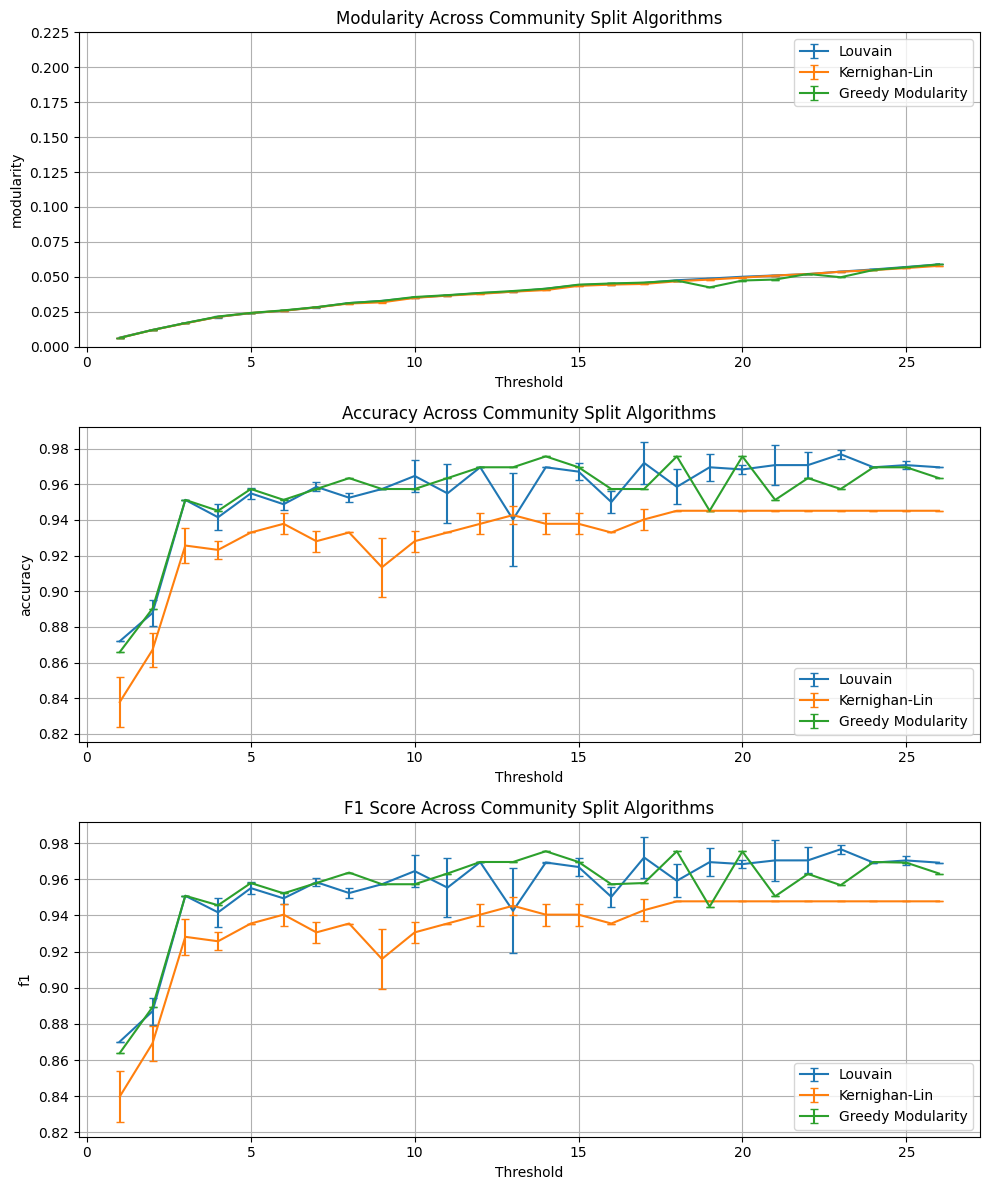

In [146]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))  # 3 rows (metrics) x 2 cols (edge types)


def plot_with_std(ax, data, edge_type, metric, title):
    for method in methods:
        mean_vals = np.array(data[edge_type][method][metric])
        std_vals = np.array(data[edge_type][method][f'{metric}_std'])

        # Calculate lower and upper bounds
        lower = np.clip(mean_vals - std_vals, 0, 1)
        upper = np.clip(mean_vals + std_vals, 0, 1)

        # Recalculate yerr as distances from mean
        lower_err = np.maximum(mean_vals - lower, 0)
        upper_err = np.maximum(upper - mean_vals, 0)

        # Combine into 2-row array for asymmetric error bars
        yerr = np.vstack((lower_err, upper_err))

        ax.errorbar(thresholds, mean_vals, yerr=yerr, label=method, capsize=3)
    
    ax.set_title(title)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)
    if metric == 'modularity':
        ax.set_ylim(0, 0.225)
    # ax.xticks(list(range(1, 31, 2)))


# Define metrics and titles
metrics = ['modularity', 'accuracy', 'f1']
titles = ['Modularity Across Community Split Algorithms', 'Accuracy Across Community Split Algorithms', 'F1 Score Across Community Split Algorithms']

# Plot loop: each row = a metric, columns = unweighted vs weighted
for i, metric in enumerate(metrics):
    plot_with_std(axs[i], weighted_and_unweighted_data, 'unweighted', metric, f'{titles[i]}')
    # plot_with_std(axs[i][1], weighted_and_unweighted_data, 'weighted', metric, f'{titles[i]} (Weighted)')

# plt.xticks(list(range(0, 31, 2)))
plt.tight_layout()
# plt.grid(True)
plt.show()

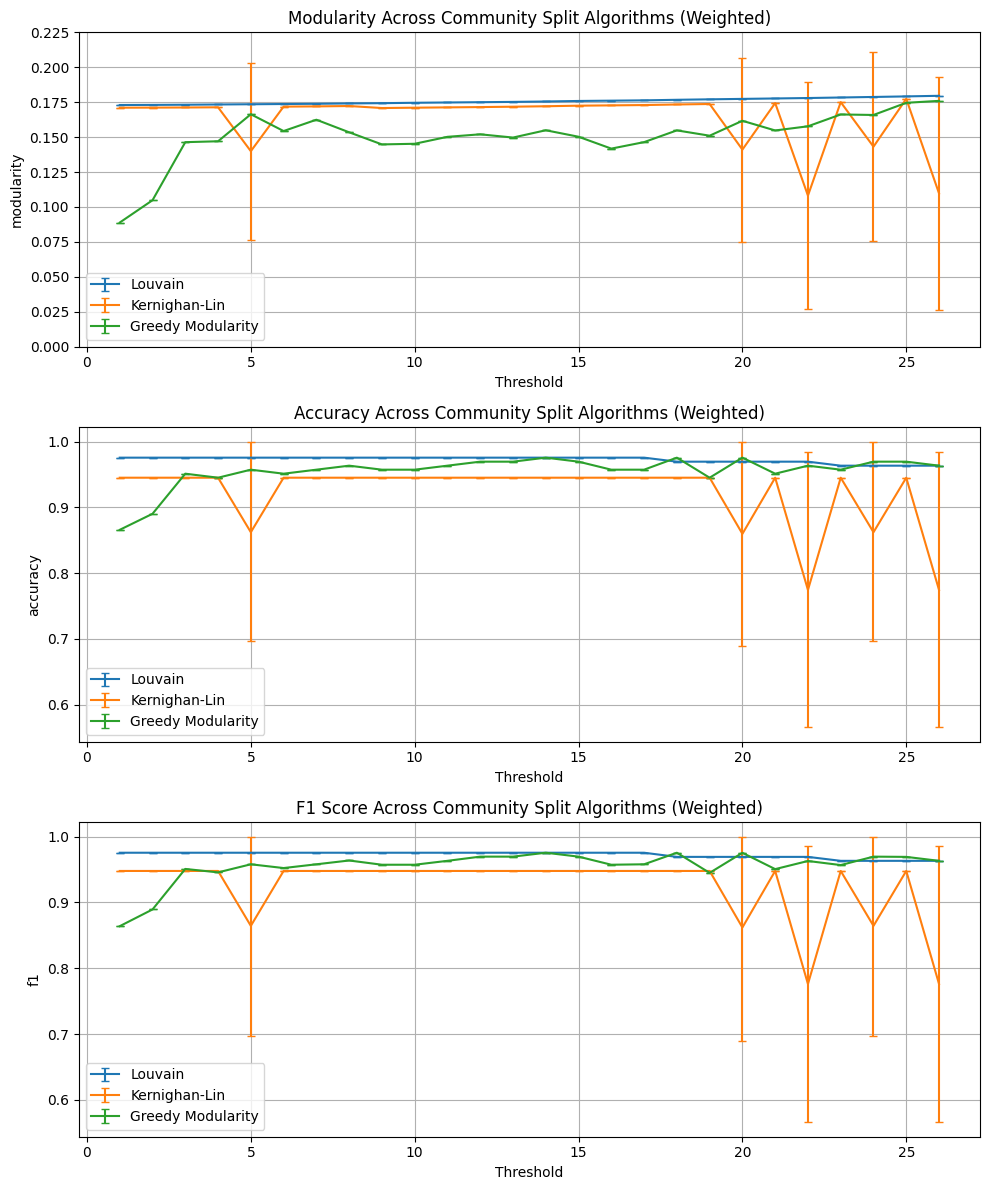

In [147]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))  # 3 rows (metrics) x 2 cols (edge types)


def plot_with_std(ax, data, edge_type, metric, title):
    for method in methods:
        mean_vals = np.array(data[edge_type][method][metric])
        std_vals = np.array(data[edge_type][method][f'{metric}_std'])

        # Calculate lower and upper bounds
        lower = np.clip(mean_vals - std_vals, 0, 1)
        upper = np.clip(mean_vals + std_vals, 0, 1)

        # Recalculate yerr as distances from mean
        lower_err = np.maximum(mean_vals - lower, 0)
        upper_err = np.maximum(upper - mean_vals, 0)

        # Combine into 2-row array for asymmetric error bars
        yerr = np.vstack((lower_err, upper_err))

        ax.errorbar(thresholds, mean_vals, yerr=yerr, label=method, capsize=3)
    
    ax.set_title(title)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)
    if metric == 'modularity':
        ax.set_ylim(0, 0.225)
    # ax.xticks(list(range(1, 31, 2)))


# Define metrics and titles
metrics = ['modularity', 'accuracy', 'f1']
titles = ['Modularity Across Community Split Algorithms', 'Accuracy Across Community Split Algorithms', 'F1 Score Across Community Split Algorithms']

# Plot loop: each row = a metric, columns = unweighted vs weighted
for i, metric in enumerate(metrics):
    # plot_with_std(axs[i], weighted_and_unweighted_data, 'unweighted', metric, f'{titles[i]} (Unweighted)')
    plot_with_std(axs[i], weighted_and_unweighted_data, 'weighted', metric, f'{titles[i]} (Weighted)')

# plt.xticks(list(range(0, 31, 2)))
plt.tight_layout()
# plt.grid(True)
plt.show()

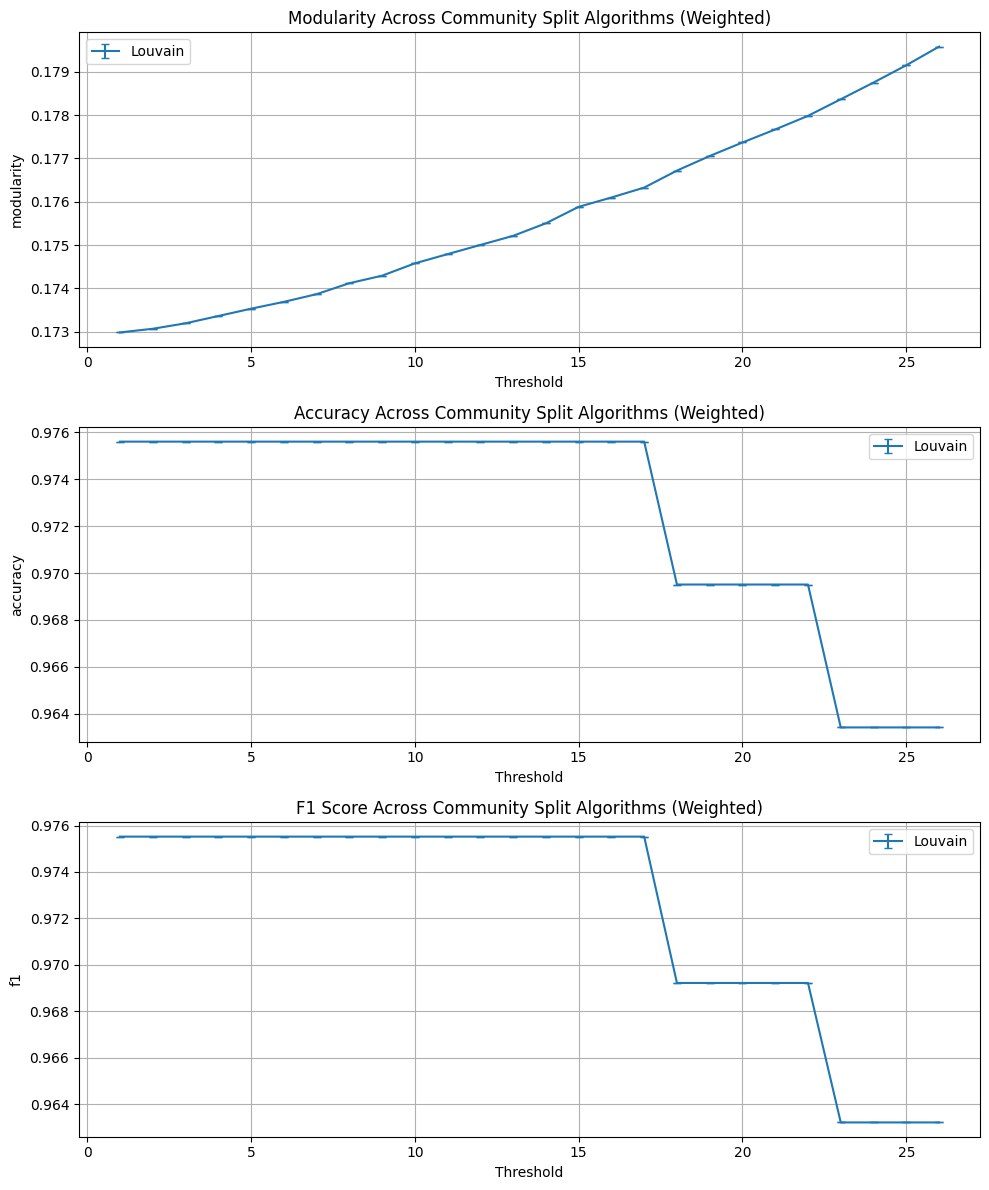

In [148]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))  # 3 rows (metrics) x 2 cols (edge types)

methods_to_plot = ['Louvain']
def plot_with_std(ax, data, edge_type, metric, title):
    for method in methods_to_plot:
        mean_vals = np.array(data[edge_type][method][metric])
        std_vals = np.array(data[edge_type][method][f'{metric}_std'])

        # Calculate lower and upper bounds
        lower = np.clip(mean_vals - std_vals, 0, 1)
        upper = np.clip(mean_vals + std_vals, 0, 1)

        # Recalculate yerr as distances from mean
        lower_err = np.maximum(mean_vals - lower, 0)
        upper_err = np.maximum(upper - mean_vals, 0)

        # Combine into 2-row array for asymmetric error bars
        yerr = np.vstack((lower_err, upper_err))

        ax.errorbar(thresholds, mean_vals, yerr=yerr, label=method, capsize=3)
    
    ax.set_title(title)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)
    # ax.xticks(list(range(1, 31, 2)))


# Define metrics and titles
metrics = ['modularity', 'accuracy', 'f1']
titles = ['Modularity Across Community Split Algorithms', 'Accuracy Across Community Split Algorithms', 'F1 Score Across Community Split Algorithms']

# Plot loop: each row = a metric, columns = unweighted vs weighted
for i, metric in enumerate(metrics):
    # plot_with_std(axs[i], weighted_and_unweighted_data, 'unweighted', metric, f'{titles[i]} (Unweighted)')
    plot_with_std(axs[i], weighted_and_unweighted_data, 'weighted', metric, f'{titles[i]} (Weighted)')

# plt.xticks(list(range(0, 31, 2)))
plt.tight_layout()
# plt.grid(True)
plt.show()

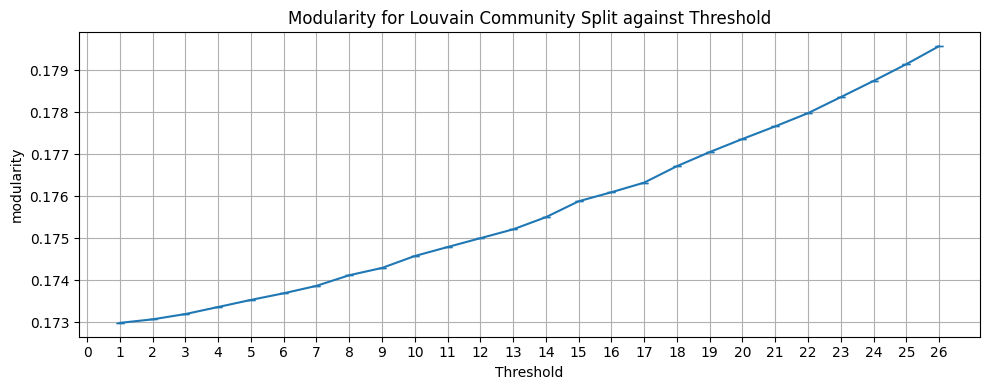

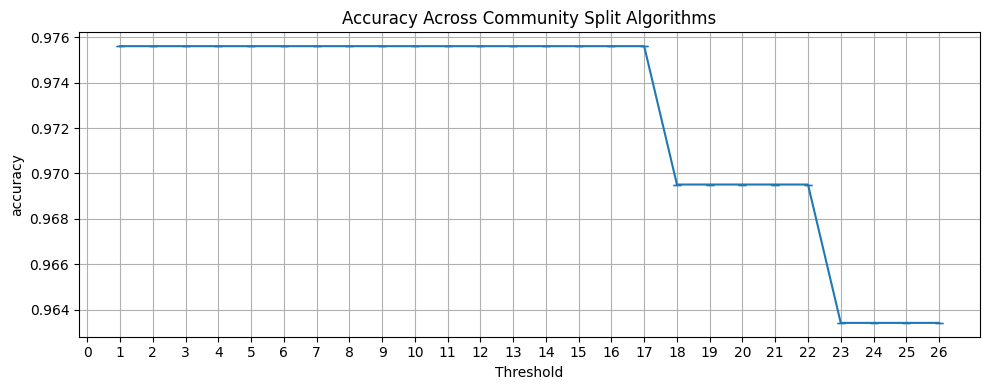

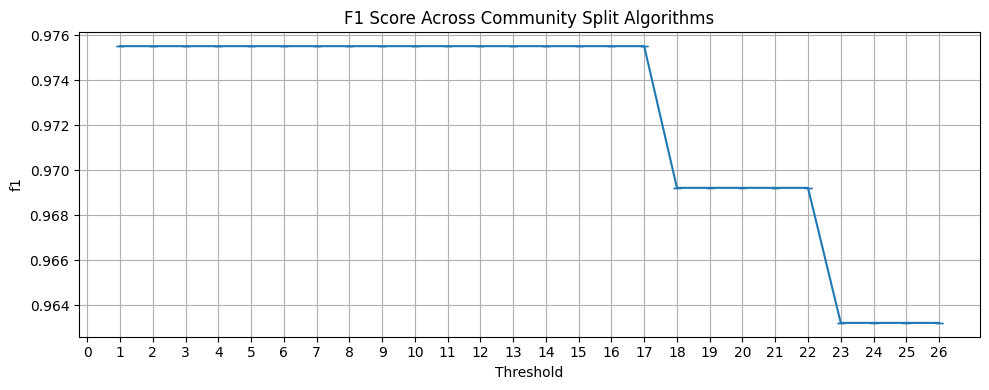

In [149]:
import matplotlib.pyplot as plt
import numpy as np

methods_to_plot = ['Louvain']  # or more if needed

def plot_with_std(data, edge_type, metric, title):
    plt.figure(figsize=(10, 4))

    for method in methods_to_plot:
        mean_vals = np.array(data[edge_type][method][metric])
        std_vals = np.array(data[edge_type][method][f'{metric}_std'])

        # Calculate and clip bounds
        lower = np.clip(mean_vals - std_vals, 0, 1)
        upper = np.clip(mean_vals + std_vals, 0, 1)
        lower_err = np.maximum(mean_vals - lower, 0)
        upper_err = np.maximum(upper - mean_vals, 0)
        yerr = np.vstack((lower_err, upper_err))

        plt.errorbar(thresholds, mean_vals, yerr=yerr, label=method, capsize=3)

    plt.title(title)
    plt.xlabel('Threshold')
    plt.ylabel(metric)
    # plt.legend()
    plt.grid(True)

    # Optional: consistent Y-limit only for modularity
    # if metric == 'modularity':
    #     plt.ylim(0, 0.22)

    # Optional: clean X-ticks
    plt.xticks(range(0, 27, 1))

    plt.tight_layout()
    plt.show()


metrics = ['modularity', 'accuracy', 'f1']
titles = [
    'Modularity for Louvain Community Split against Threshold',
    'Accuracy Across Community Split Algorithms',
    'F1 Score Across Community Split Algorithms'
]

for metric, title in zip(metrics, titles):
    plot_with_std(weighted_and_unweighted_data, 'weighted', metric, f'{title}')


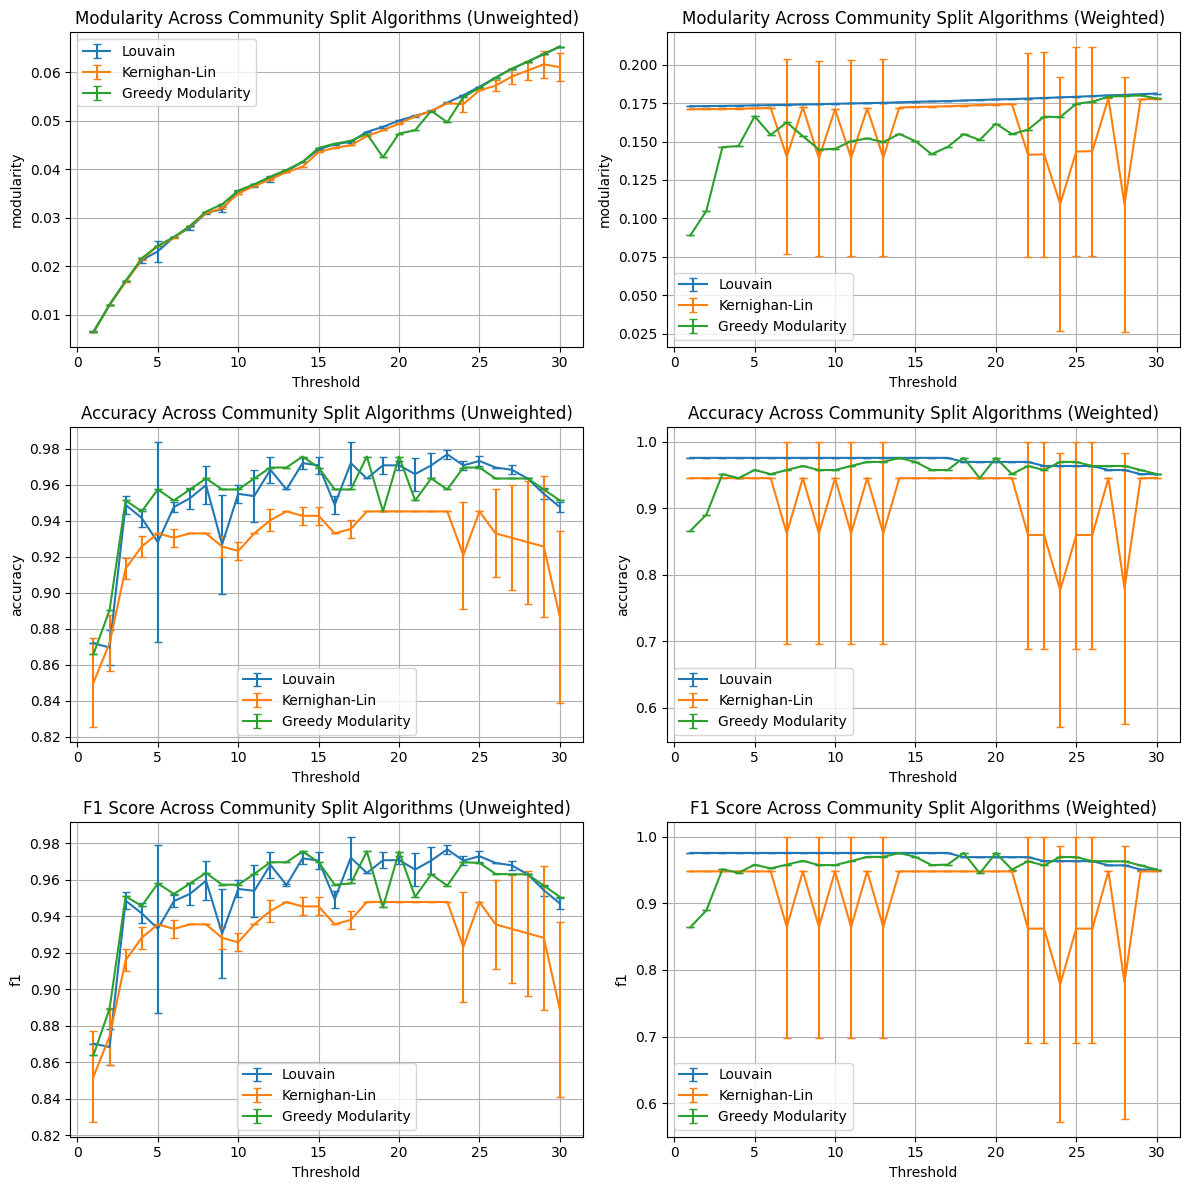

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows (metrics) x 2 cols (edge types)


methods_to_plot = ['Louvain', 'Kernighan-Lin', 'Greedy Modularity']


def plot_with_std(ax, data, edge_type, metric, title):
    for method in methods_to_plot:
        mean_vals = np.array(data[edge_type][method][metric])
        std_vals = np.array(data[edge_type][method][f'{metric}_std'])

        # Calculate lower and upper bounds
        lower = np.clip(mean_vals - std_vals, 0, 1)
        upper = np.clip(mean_vals + std_vals, 0, 1)

        # Recalculate yerr as distances from mean
        lower_err = np.maximum(mean_vals - lower, 0)
        upper_err = np.maximum(upper - mean_vals, 0)

        # Combine into 2-row array for asymmetric error bars
        yerr = np.vstack((lower_err, upper_err))

        ax.errorbar(thresholds, mean_vals, yerr=yerr, label=method, capsize=3)
    
    ax.set_title(title)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)
    # ax.xticks(list(range(1, 31, 2)))


# Define metrics and titles
metrics = ['modularity', 'accuracy', 'f1']
titles = ['Modularity Across Community Split Algorithms', 'Accuracy Across Community Split Algorithms', 'F1 Score Across Community Split Algorithms']

# Plot loop: each row = a metric, columns = unweighted vs weighted
for i, metric in enumerate(metrics):
    plot_with_std(axs[i][0], weighted_and_unweighted_data, 'unweighted', metric, f'{titles[i]} (Unweighted)')
    plot_with_std(axs[i][1], weighted_and_unweighted_data, 'weighted', metric, f'{titles[i]} (Weighted)')

# plt.xticks(list(range(0, 31, 2)))
plt.tight_layout()
# plt.grid(True)
plt.show()